# HOMEWORK 8

In this homework you are going to implement your first machine learning algorithm to automatically binarize document images. The goal of document binarization is to separate the characters (letters) from everything else. This is the crucial part for automatic document understanding and information extraction from scanned or photographed documents. In order to do so, you will use the Otsu thresholding algorithm.

At the end of this notebook, there are a couple of questions for you to answer.

In [1]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Let's load the document image we will be working on in this homework.

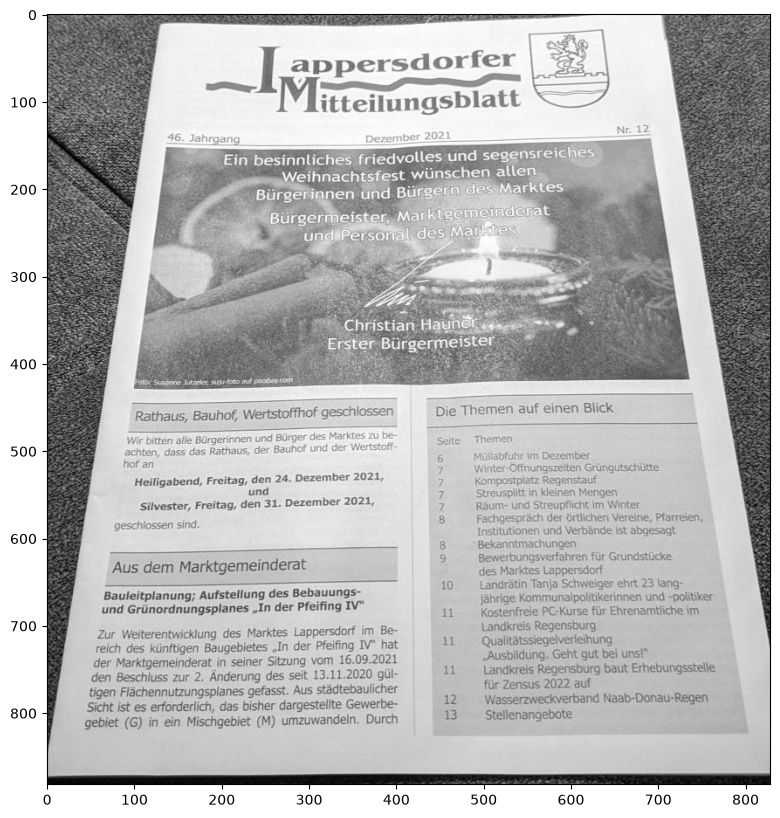

In [2]:
img = cv2.imread('../data/document.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img, cmap='gray')

First, let's have a look at the histogram.

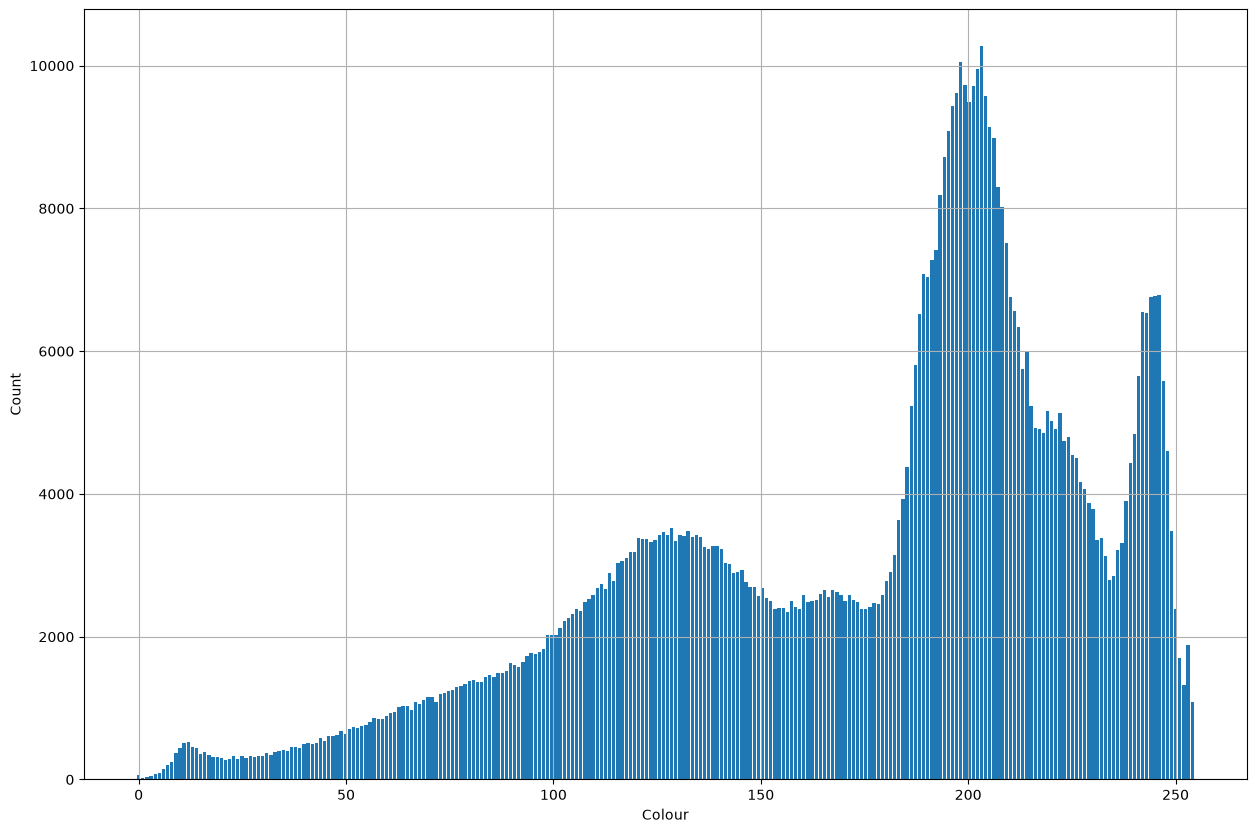

In [3]:
h = np.histogram(img, 256)
plt.bar(h[1][0:-1], h[0])
plt.xlabel('Colour'), plt.ylabel('Count')
plt.grid(True)

### Otsu Thresholding

Let's now implement the Otsu thresholding algorithm. Remember that the algorithm consists of an optimization process that finds the threshold $\theta$ that minimizes the intra-class (within-class) variance or, equivalently, maximizes the inter-class (between-class) variance.

The threshold $\theta$ splits the pixels into two classes: the **foreground** (the characters, i.e. the dark pixels with a gray level $\le \theta$) and the **background** (the paper, i.e. the bright pixels with a gray level $> \theta$). The within-class variance is the weighted sum of the variances of the two classes

$$ \sigma^2_{wcv}(\theta) = \omega_F(\theta)\,\sigma^2_F(\theta) + \omega_B(\theta)\,\sigma^2_B(\theta), \qquad \omega_{F/B}(\theta) = \frac{N_{F/B}(\theta)}{N} $$

where $N_F(\theta)$ and $N_B(\theta)$ are the numbers of foreground and background pixels, $N$ is the total number of pixels (so that $\omega_F + \omega_B = 1$) and $\sigma^2_F$, $\sigma^2_B$ are the variances of the gray levels inside each of the classes. The variables in the code below follow this notation (`omega_f`, `omega_b`, `sigma2_f`, `sigma2_b`).

In this homework, you are going to demonstrate the working principle of the Otsu algorithm. Therefore, you won't have to worry about an efficient implementation, we are going to use the brute force approach here: try all 256 thresholds and keep the one with the lowest within-class variance.

In [13]:
# Get image dimensions
rows, cols = img.shape
# Compute the total amount of image pixels
num_pixels = rows * cols

# Initializations
best_wcv = np.inf  # Best within-class variance (wcv)
opt_th = None      # Threshold corresponding to the best wcv

# Brute force search using all possible thresholds (levels of gray)
for th in range(0, 256):
    # Extract the image pixels corresponding to the foreground
    foreground = img[img < th]
    # Extract the image pixels corresponding to the background
    background = img[img > th]
    
    # If foreground or background are empty, continue
    # (such a threshold does not split the image and the variance of an empty set is undefined)
    if len(foreground) == 0 or len(background) == 0:
        continue
    
    # Compute class-weights (omega parameters) for foreground and background
    omega_f = len(foreground) / num_pixels
    omega_b = 1 - omega_f
    
    # Compute pixel variance for foreground and background
    # Hint: Check out the var function from numpy ;-)
    # https://numpy.org/doc/stable/reference/generated/numpy.var.html
    sigma2_f = np.var(foreground)
    sigma2_b = np.var(background)
    
    # Compute the within-class variance
    wcv = np.sqrt(omega_f * sigma2_f + omega_b * sigma2_b)
    
    # Perform the optimization
    if wcv < best_wcv:
        best_wcv = wcv
        opt_th = th
        
# Print out the optimal threshold found by Otsu algorithm
print('Optimal threshold', opt_th)

Optimal threshold 159


### Check your result

OpenCV ships with its own implementation of the Otsu algorithm. Let's compare its threshold with the one you have found.

In [4]:
otsu_th, _ = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print('OpenCV Otsu threshold:', otsu_th)

OpenCV Otsu threshold: 159.0


Finally, let's compare the original image and its thresholded representation.

(<Axes: >, <matplotlib.image.AxesImage at 0x7b33b8a91d90>)

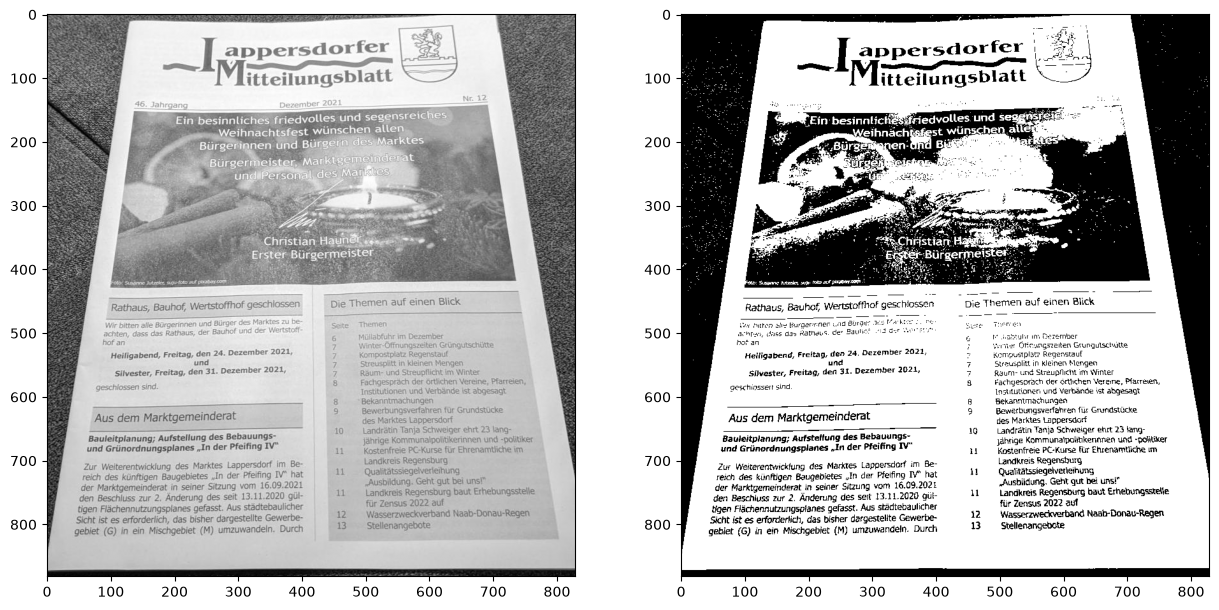

In [14]:
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.subplot(122), plt.imshow(img > opt_th, cmap='gray')

OpenCV Otsu threshold: 101.0


(<Axes: >, <matplotlib.image.AxesImage at 0x7b33b8771b80>)

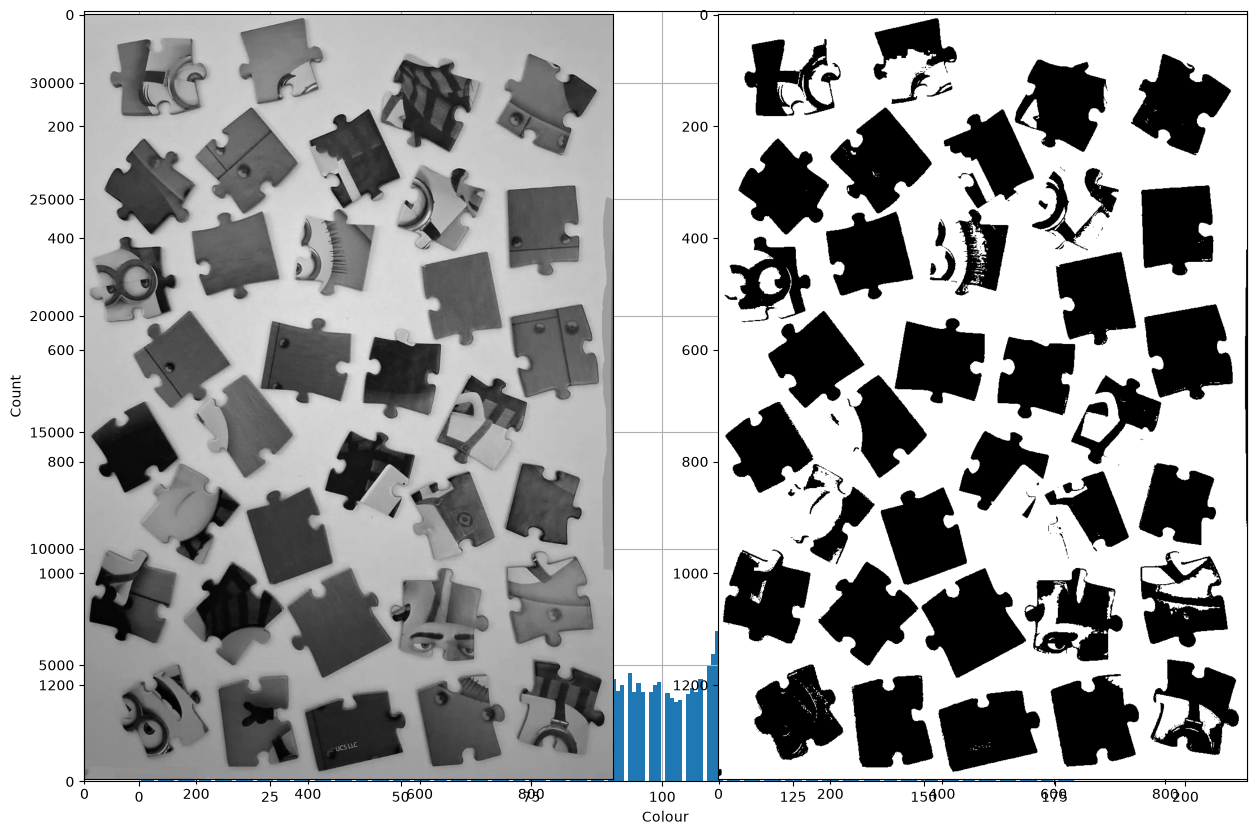

In [26]:
imgTest = cv2.imread("../data/puzzle_2.jpeg")
imgTest = cv2.cvtColor(imgTest, cv2.COLOR_BGR2RGB)
imgTest = cv2.cvtColor(imgTest, cv2.COLOR_RGB2GRAY)

h = np.histogram(imgTest, 256)
plt.bar(h[1][0:-1], h[0])
plt.xlabel('Colour'), plt.ylabel('Count')
plt.grid(True)

In [ ]:
otsu_th, _ = cv2.threshold(imgTest, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print('OpenCV Otsu threshold:', otsu_th)
plt.subplot(121), plt.imshow(imgTest, cmap='gray')
plt.subplot(122), plt.imshow(imgTest > otsu_th, cmap='gray')

### Questions

* Looking at the computed histogram, could it be considered bimodal?
  It is not obvious to say the the image is bimodal? because Histogram shows ecplicitly two groups of brightnesses that have big amount of pixels but their share is not dramatically obvious. 
* Looking at the computed histogram, what binarization threshold would you chose? Why?
  I would probable choose between theshold values around 175 and 230. But the look at the image shows that in order to extract text I need to get reed of all background styles (both white paper and darkened text blocks). That is why I would choose the value 175.
* Looking at the resulting (thresholded) image, is the text binarization (detection) good? The resulting image shows the possible usage cases of binarisation detection: it is good for text that has almost uniform background (I believe it can do a good job in cases with shadows when the image is taken from above and "I can see the shadow from my hand" :). However I is not suitable for cases when the text is placed above another image. Considering other usages I have a fantasy that this method can work good for counting, for example, tablets in box (conveyer put 93 tablets on white palette, but you need only 90 of them).